# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The BMW Global Automotive Sales Dataset](https://www.kaggle.com/datasets/dmahajanbe23/bmw-global-automotive-sales/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/bmw-global-automotive-sales/bmw_global_sales_2018_2025.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('bmw_global_sales_2018_2025.csv)

# Preprocessing

## Frist five row

In [3]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


## last Five row

In [4]:
df.tail()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41
3071,2025,12,RestOfWorld,MINI,6732,41811,281471652,0.167,5.89,2.37,1.41


## Shape of our dataset

In [5]:
df.shape

(3072, 11)

## List out all columns

In [6]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Year                  int64
Month                 int64
Region               object
Model                object
Units_Sold            int64
Avg_Price_EUR         int64
Revenue_EUR           int64
BEV_Share           float64
Premium_Share       float64
GDP_Growth          float64
Fuel_Price_Index    float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

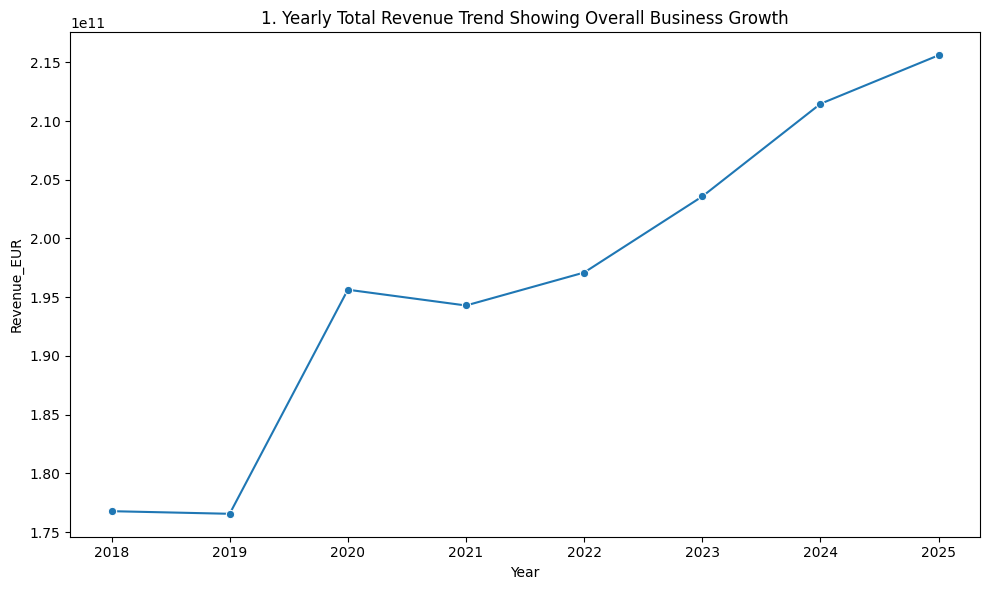

In [13]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.groupby('Year')['Revenue_EUR'].sum().reset_index(), x='Year', y='Revenue_EUR', marker='o')
plt.title(f'{plot_no}. Yearly Total Revenue Trend Showing Overall Business Growth')
show_fig()
plot_no += 1

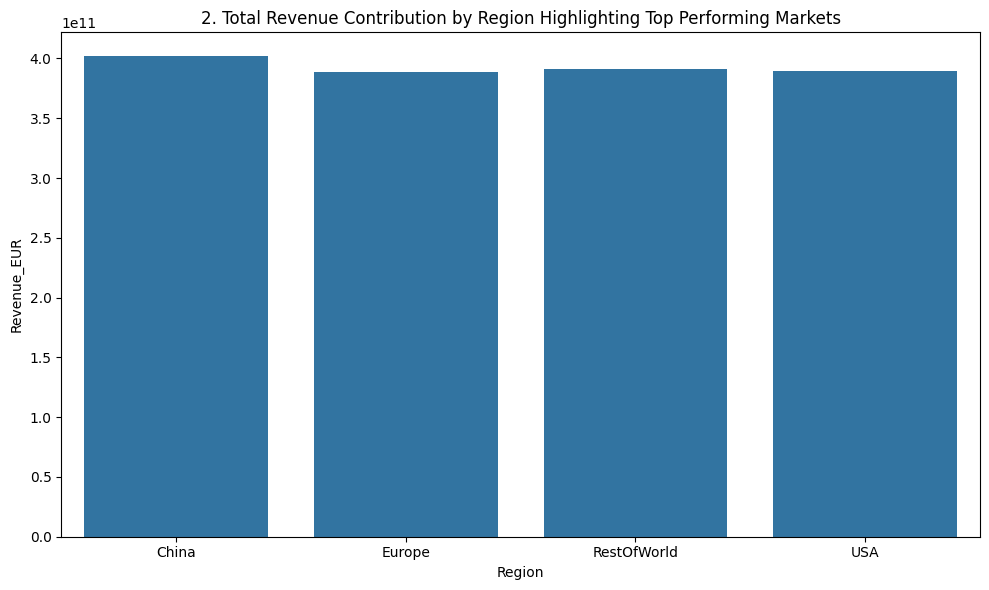

In [14]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df.groupby('Region')['Revenue_EUR'].sum().reset_index(), x='Region', y='Revenue_EUR')
plt.title(f'{plot_no}. Total Revenue Contribution by Region Highlighting Top Performing Markets')
show_fig()
plot_no += 1

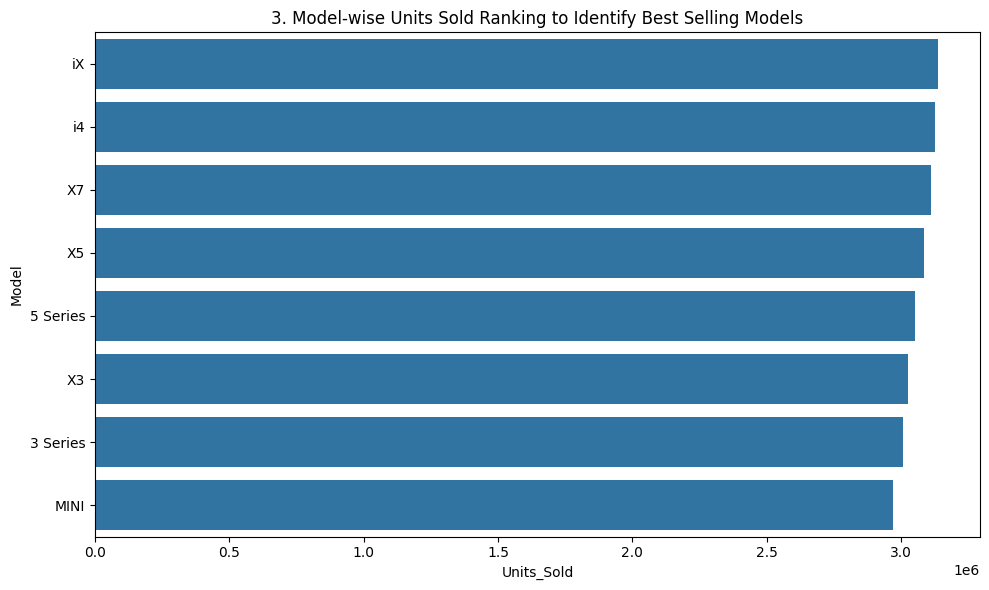

In [15]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df.groupby('Model')['Units_Sold'].sum().reset_index().sort_values('Units_Sold', ascending=False), x='Units_Sold', y='Model')
plt.title(f'{plot_no}. Model-wise Units Sold Ranking to Identify Best Selling Models')
show_fig()
plot_no += 1

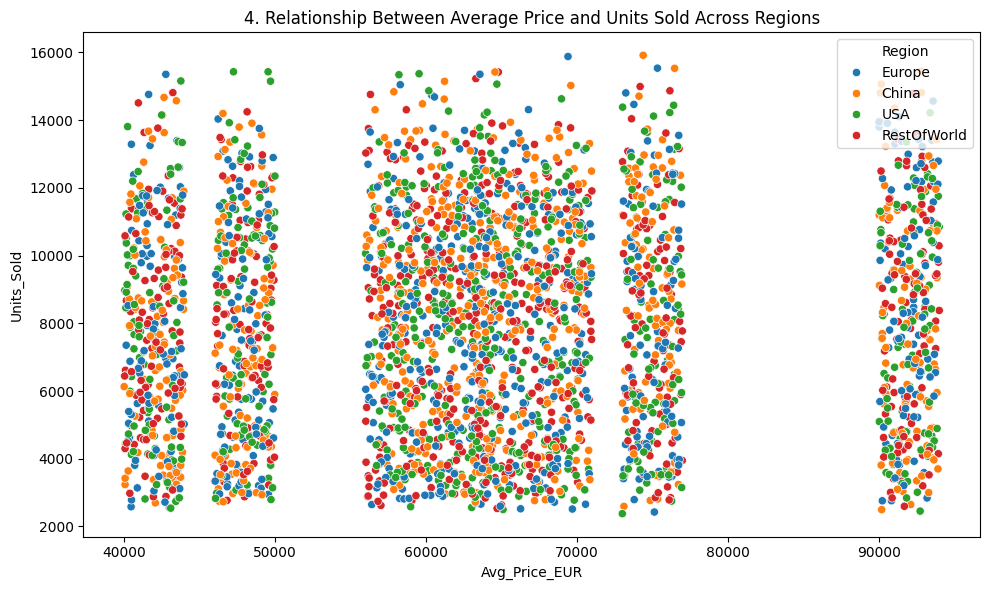

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Avg_Price_EUR', y='Units_Sold', hue='Region')
plt.title(f'{plot_no}. Relationship Between Average Price and Units Sold Across Regions')
show_fig()
plot_no += 1

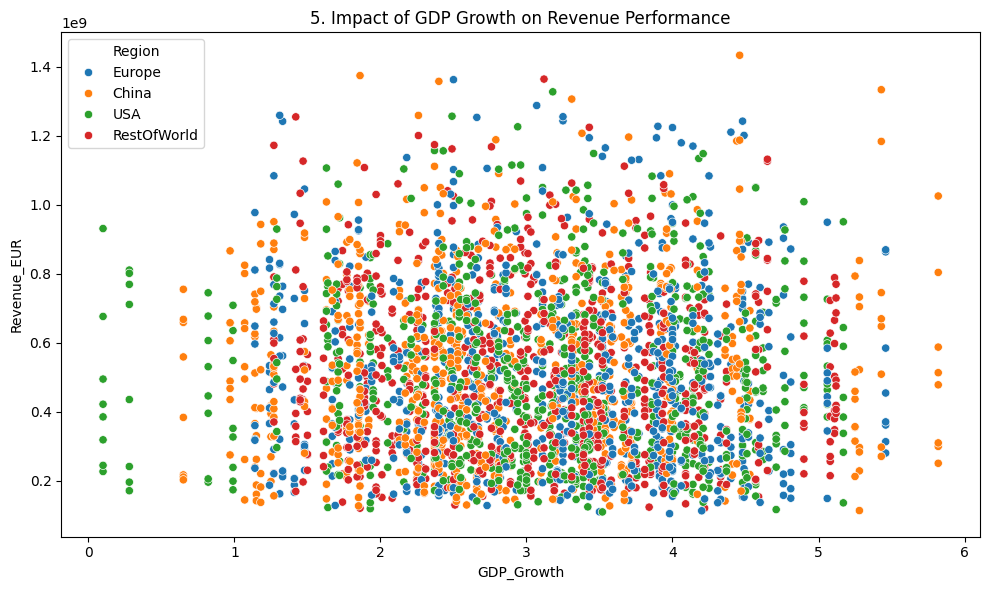

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='GDP_Growth', y='Revenue_EUR', hue='Region')
plt.title(f'{plot_no}. Impact of GDP Growth on Revenue Performance')
show_fig()
plot_no += 1

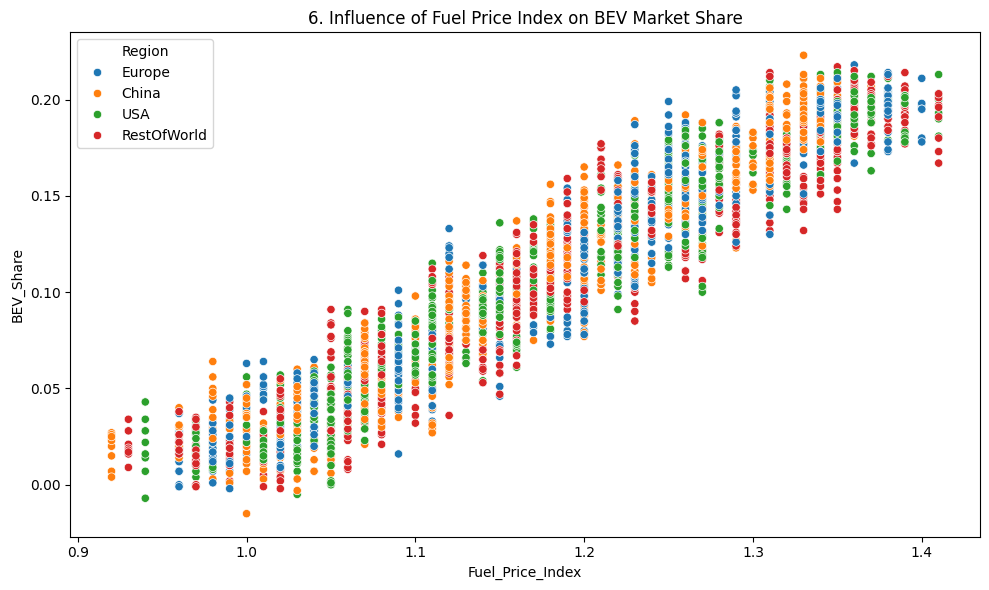

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Fuel_Price_Index', y='BEV_Share', hue='Region')
plt.title(f'{plot_no}. Influence of Fuel Price Index on BEV Market Share')
show_fig()
plot_no += 1

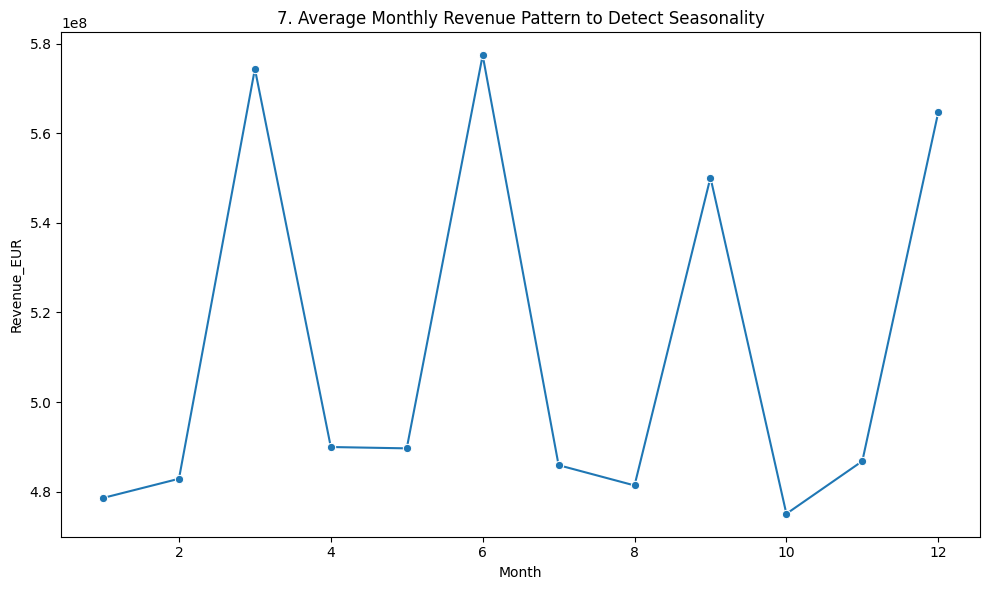

In [19]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.groupby('Month')['Revenue_EUR'].mean().reset_index(), x='Month', y='Revenue_EUR', marker='o')
plt.title(f'{plot_no}. Average Monthly Revenue Pattern to Detect Seasonality')
show_fig()
plot_no += 1

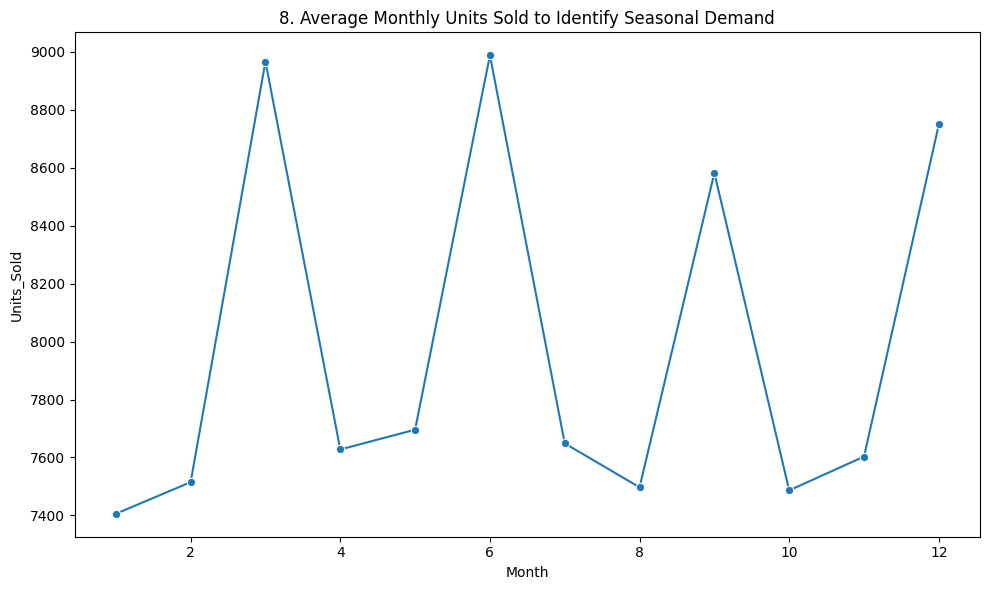

In [20]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.groupby('Month')['Units_Sold'].mean().reset_index(), x='Month', y='Units_Sold', marker='o')
plt.title(f'{plot_no}. Average Monthly Units Sold to Identify Seasonal Demand')
show_fig()
plot_no += 1

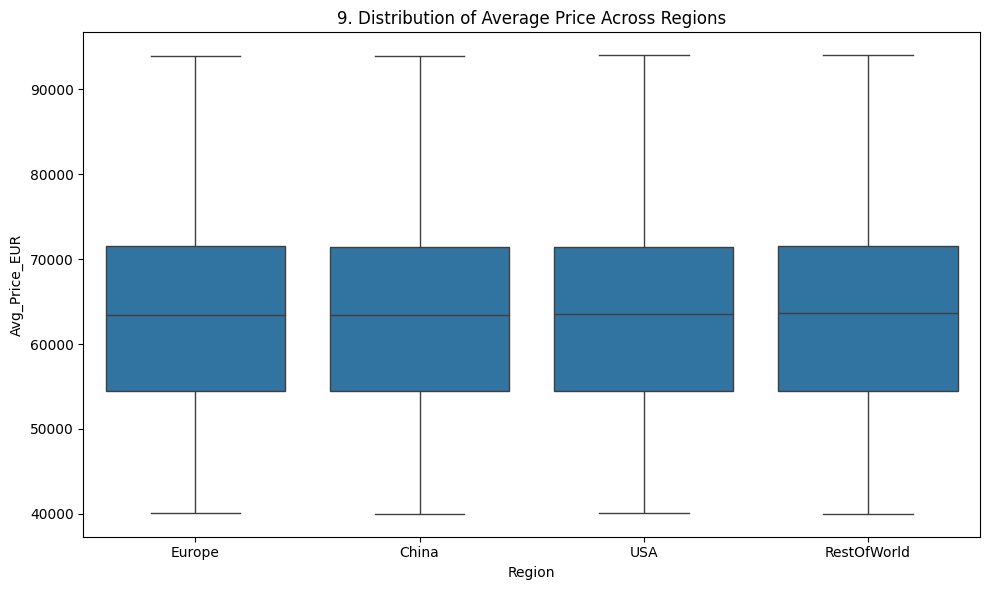

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Region', y='Avg_Price_EUR')
plt.title(f'{plot_no}. Distribution of Average Price Across Regions')
show_fig()
plot_no += 1

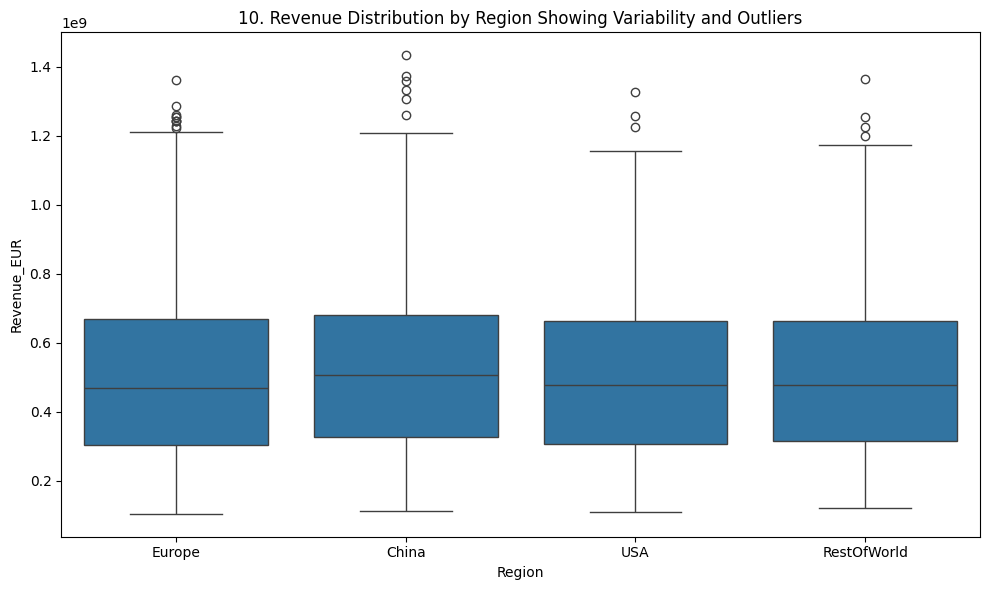

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Region', y='Revenue_EUR')
plt.title(f'{plot_no}. Revenue Distribution by Region Showing Variability and Outliers')
show_fig()
plot_no += 1

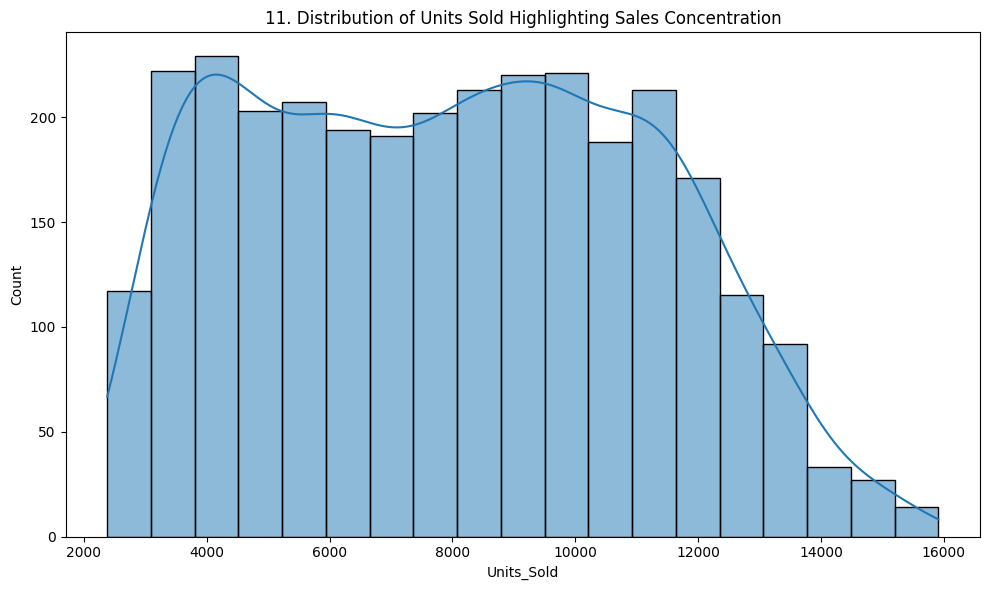

In [23]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Units_Sold'], kde=True)
plt.title(f'{plot_no}. Distribution of Units Sold Highlighting Sales Concentration')
show_fig()
plot_no += 1

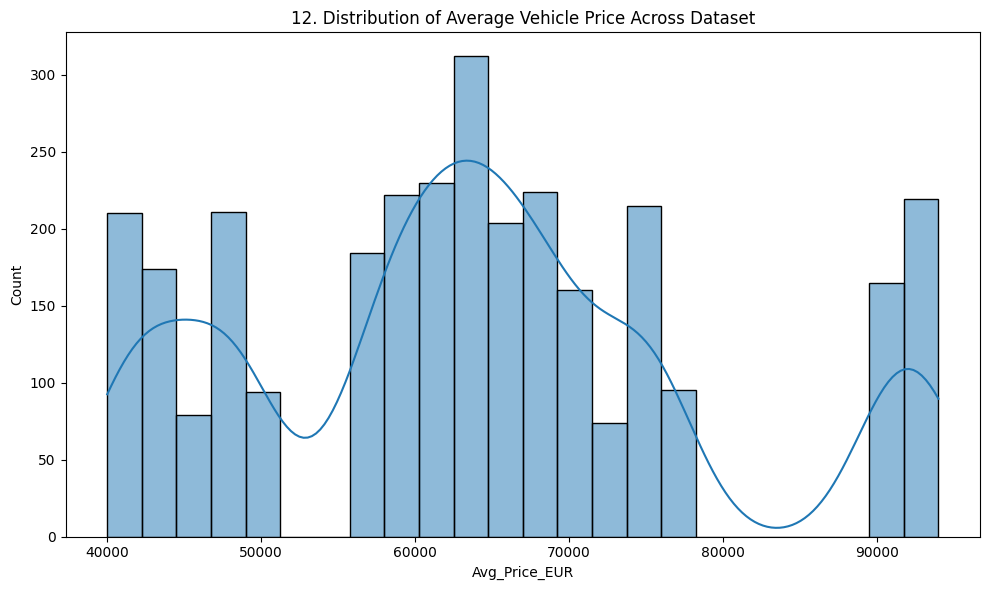

In [24]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Avg_Price_EUR'], kde=True)
plt.title(f'{plot_no}. Distribution of Average Vehicle Price Across Dataset')
show_fig()
plot_no += 1

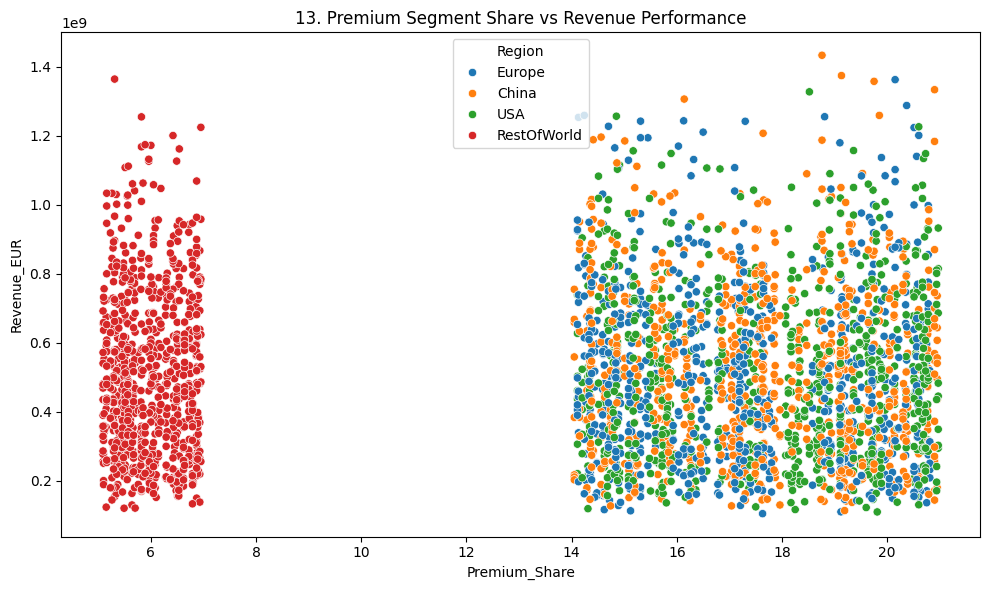

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Premium_Share', y='Revenue_EUR', hue='Region')
plt.title(f'{plot_no}. Premium Segment Share vs Revenue Performance')
show_fig()
plot_no += 1

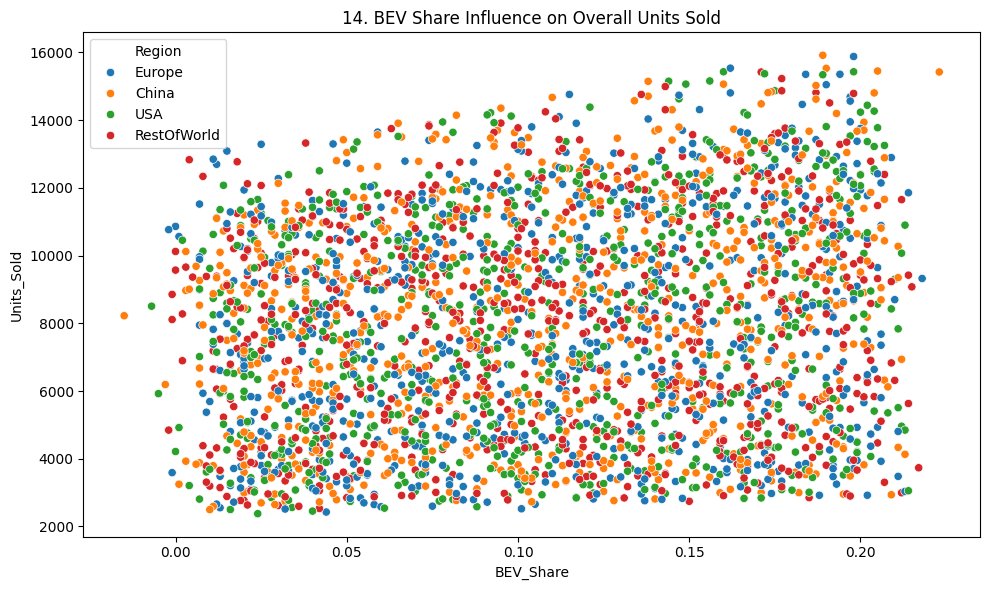

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='BEV_Share', y='Units_Sold', hue='Region')
plt.title(f'{plot_no}. BEV Share Influence on Overall Units Sold')
show_fig()
plot_no += 1

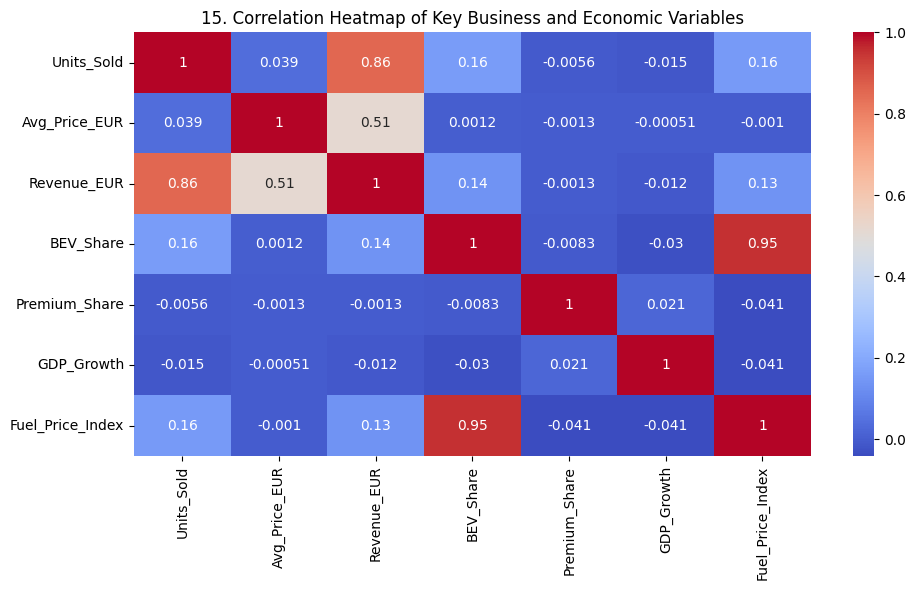

In [27]:
fig = plt.figure(figsize=(10,6))
corr = df[['Units_Sold','Avg_Price_EUR','Revenue_EUR','BEV_Share','Premium_Share','GDP_Growth','Fuel_Price_Index']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Key Business and Economic Variables')
show_fig()
plot_no += 1

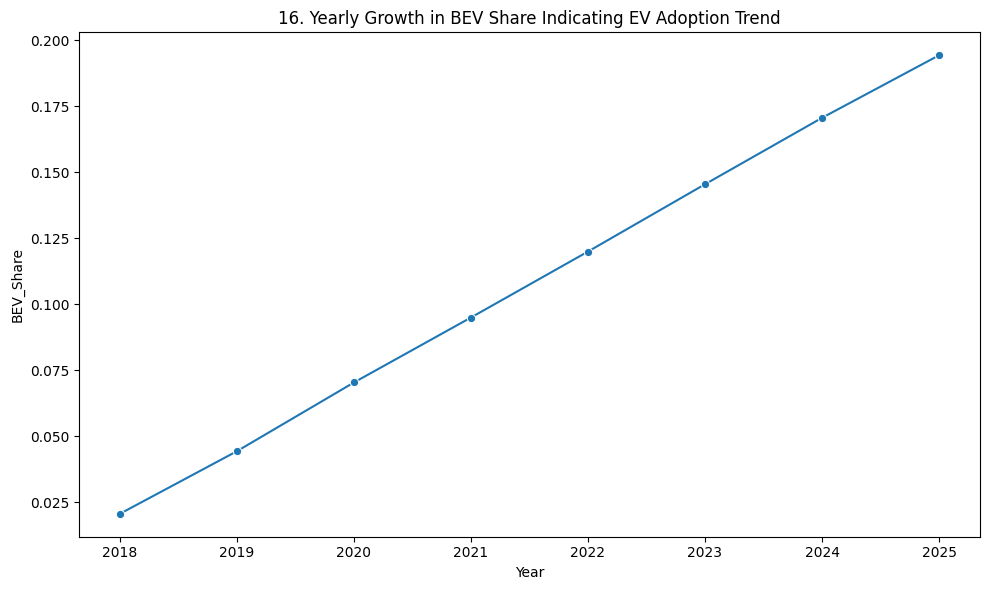

In [28]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.groupby('Year')['BEV_Share'].mean().reset_index(), x='Year', y='BEV_Share', marker='o')
plt.title(f'{plot_no}. Yearly Growth in BEV Share Indicating EV Adoption Trend')
show_fig()
plot_no += 1

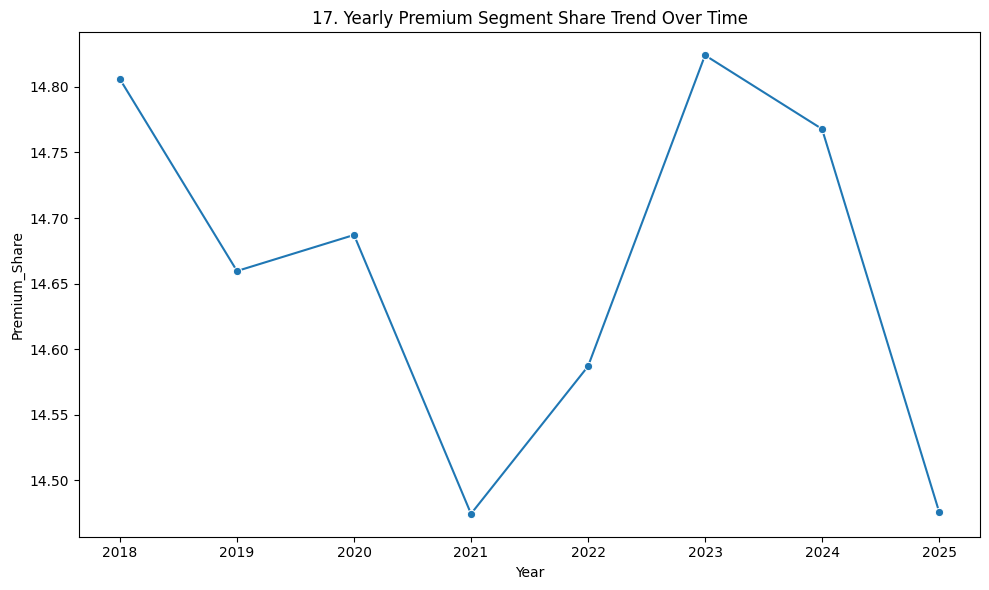

In [29]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.groupby('Year')['Premium_Share'].mean().reset_index(), x='Year', y='Premium_Share', marker='o')
plt.title(f'{plot_no}. Yearly Premium Segment Share Trend Over Time')
show_fig()
plot_no += 1

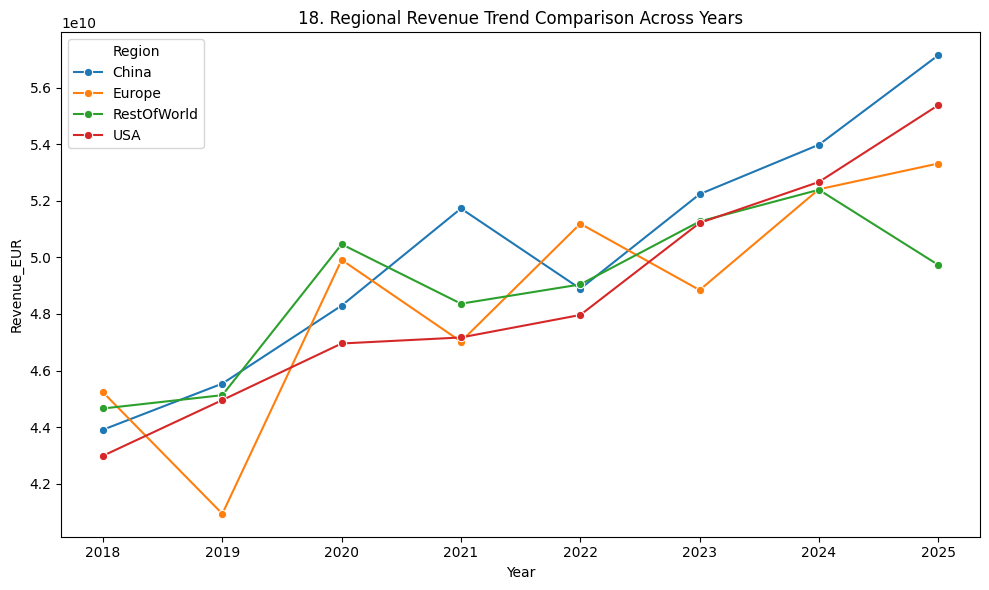

In [30]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.groupby(['Year','Region'])['Revenue_EUR'].sum().reset_index(), x='Year', y='Revenue_EUR', hue='Region', marker='o')
plt.title(f'{plot_no}. Regional Revenue Trend Comparison Across Years')
show_fig()
plot_no += 1

# Model Training

## Create binary target based on median Revenue

In [31]:
df['High_Revenue'] = (df['Revenue_EUR'] > df['Revenue_EUR'].median()).astype(int)

## Define features and target variable

In [32]:
X = df[['Units_Sold','Avg_Price_EUR','BEV_Share','Premium_Share','GDP_Growth','Fuel_Price_Index']]
y = df['High_Revenue']

## Split dataset into training and testing sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Scale features for better model performance

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Logistic Regression model

In [35]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Predict on test data

In [36]:
y_pred = model.predict(X_test)

## Calculate and print accuracy score

In [37]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9596354166666666


## Plot Confusion Matrix

<Figure size 800x600 with 0 Axes>

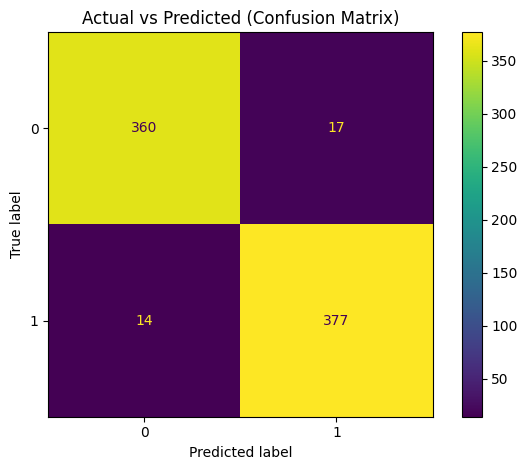

In [38]:
fig = plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Actual vs Predicted (Confusion Matrix)")
plt.tight_layout()
plt.show()